In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
wid = 64
oversample = 4

nwavels = 7#13#6
npoly=1#10#2

n_zernikes = 20#30#12

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = "../data/MAST_2024-09-08T07_59_18.213Z/HST/"

files = [
    # F095N
    "n43ca5fjq_cal.fits",
    "n43ca5fkq_cal.fits",
    "n43ca5flq_cal.fits",
    "n43ca5fmq_cal.fits",
    #F190N
    "n43ca5feq_cal.fits",
    "n43ca5ffq_cal.fits",
    "n43ca5fgq_cal.fits",
    "n43ca5fhq_cal.fits",
    #F187N
    #"n43c03dnq_cal.fits",
    #"n43c03doq_cal.fits",
    #"n43c03dpq_cal.fits",
    #"n43c03drq_cal.fits",
    #F108N
    #"n43c03dsq_cal.fits",
    #"n43c03duq_cal.fits",
    ##"n43c03dvq_cal.fits",
    ##"n43c03dwq_cal.fits",
][-1:]

exposures_single = [
    exposure_from_file(ddir + "n43ca5fhq_cal.fits", SinglePointFit(spectrum_basis, "F190N"), crop=wid),
    #exposure_from_file(ddir + "n43c03dsq_cal.fits", SinglePointFit(spectrum_basis, "F108N"), crop=wid),
    ]



W0512 11:54:52.747856 24042699 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Version 4.4.0
124 52


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [4]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

50934.93448622
SAO179809-PSF
F190N
19.93641


In [5]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 10.,
    "bias": {},
    "jitter": {},

    "defocus": {},
    "despace": {},
    "mag": 3.3,
    "quadrature": {},
}

positions = [[0.,0.,],[0.,0.,],[0.,0.,],[0.,0.,]]#[[0.43251792, 0.33013815],[ 0.49417186, -0.5629123 ]]


for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))

    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)

    # params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.asarray([ 21.9267203 , -14.20133333, -27.77798078, -28.44491861,
    #       -5.48501933,  -8.87418317,  23.78868922,   7.46177568,
    #       -0.2863787 , -13.39340241,  -4.89880687,   4.25452262,
    #       -4.49137758,   3.42268926,   4.09896897,  -3.15079696,
    #        1.90339653,  -5.20437772,   5.11727282,   1.82359044])#np.zeros(n_zernikes)#np.asarray([0., 24.884588  , -25.489779  , -17.15699   , -21.790146  ,
    #      -4.592212  ,  -4.832893  ,  19.196083  ,   0.37983412,
    #       7.0756216 ,   0.30277824,  -6.330534])#np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.,8.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    params["despace"][exp.fit.get_key(exp, "despace")] = 0.#-5.#0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample

    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = np.array(0.)


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

20.01818757730746


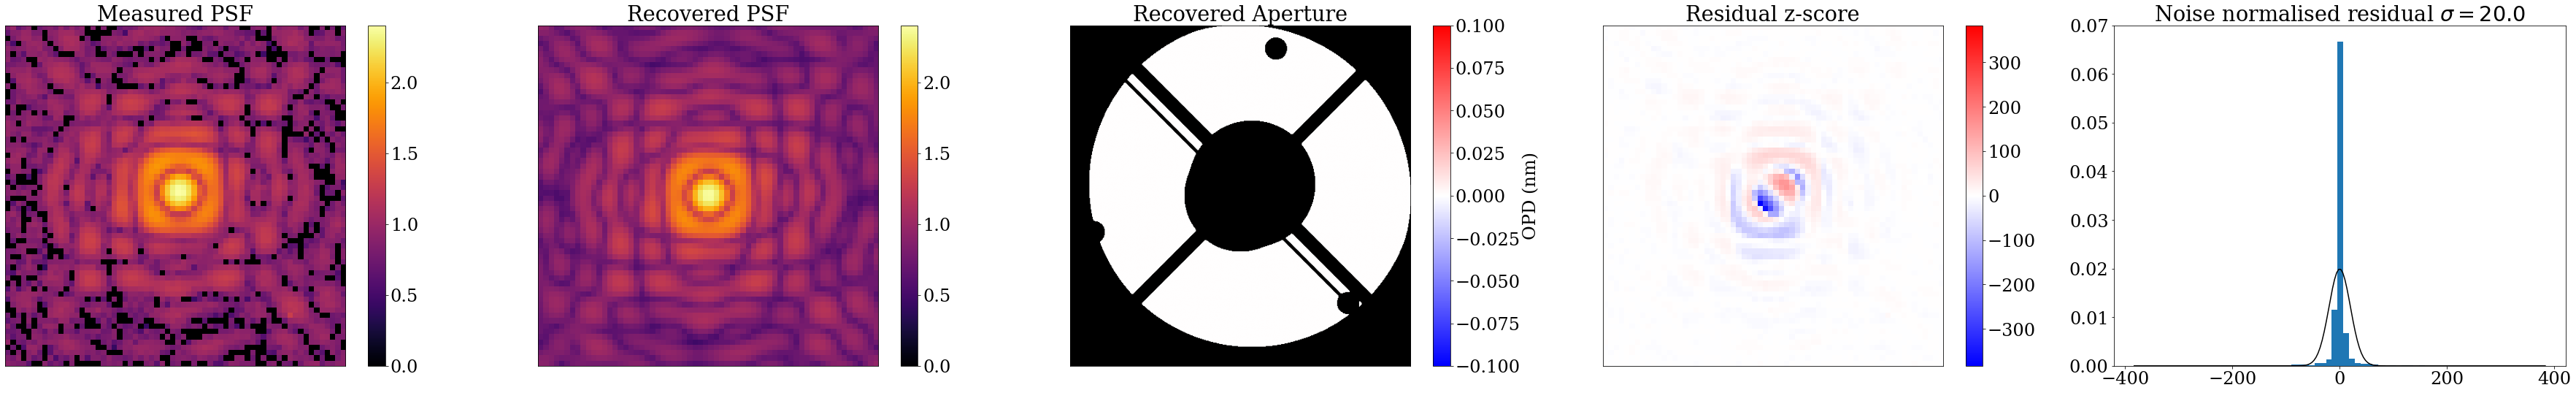

In [6]:
plot_comparison(model_single, params, exposures_single)

In [7]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)


g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*3, 10),
    "cold_mask_shift": sgd(g*10, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*2, 70),
    #"jitter": opt(g*1, 120),

    "despace": sgd(g*10, 50),
    "mag": sgd(g*3, 100),

    "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*20, 400)
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [8]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [9]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

[4.05435397e-07 3.78435663e-07]


  0%|          | 0/10 [00:00<?, ?it/s]

5.900072776282501


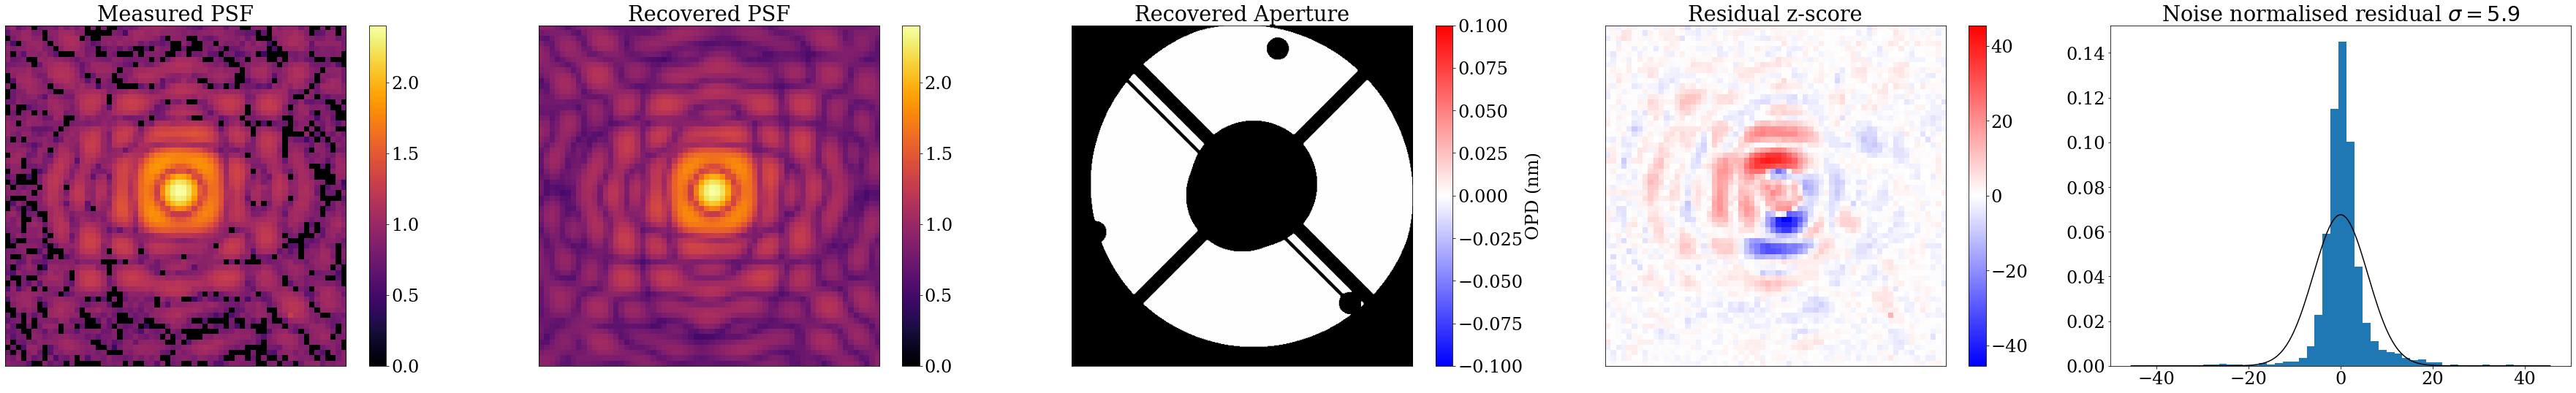

In [10]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [11]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [12]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500)

[5.19372347e-01 1.21046589e-01 1.88594608e-02 1.49961183e-02
 1.41652212e-02 1.39088426e-02 7.23608781e-02 4.79621723e-02
 8.80985696e-02 1.16526909e-01 1.18438719e-01 2.89803015e-02
 3.35322663e-02 1.48953483e-02 1.55044163e-02 2.74686950e-02
 2.60194269e-02 9.17498588e-02 1.07135434e-01 5.10612982e-02
 4.91805307e-06 1.65894120e-04 1.61056228e-04 2.36954314e-04
 2.26065355e-04 2.97903934e-03 1.40103647e-07 8.01865270e-07
 7.58247751e-07 6.54019667e-07 6.82859667e+00]


  0%|          | 0/500 [00:00<?, ?it/s]

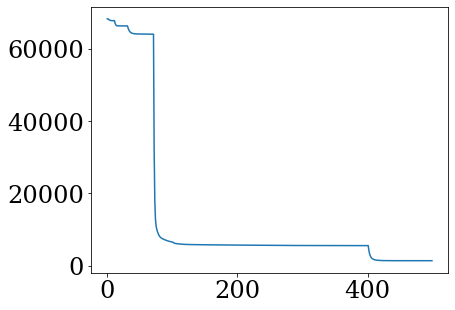

In [13]:
plt.plot(losses[:])

In [14]:
losses[-1]

Array(1375.29629445, dtype=float64)

9
0.9984261200925295


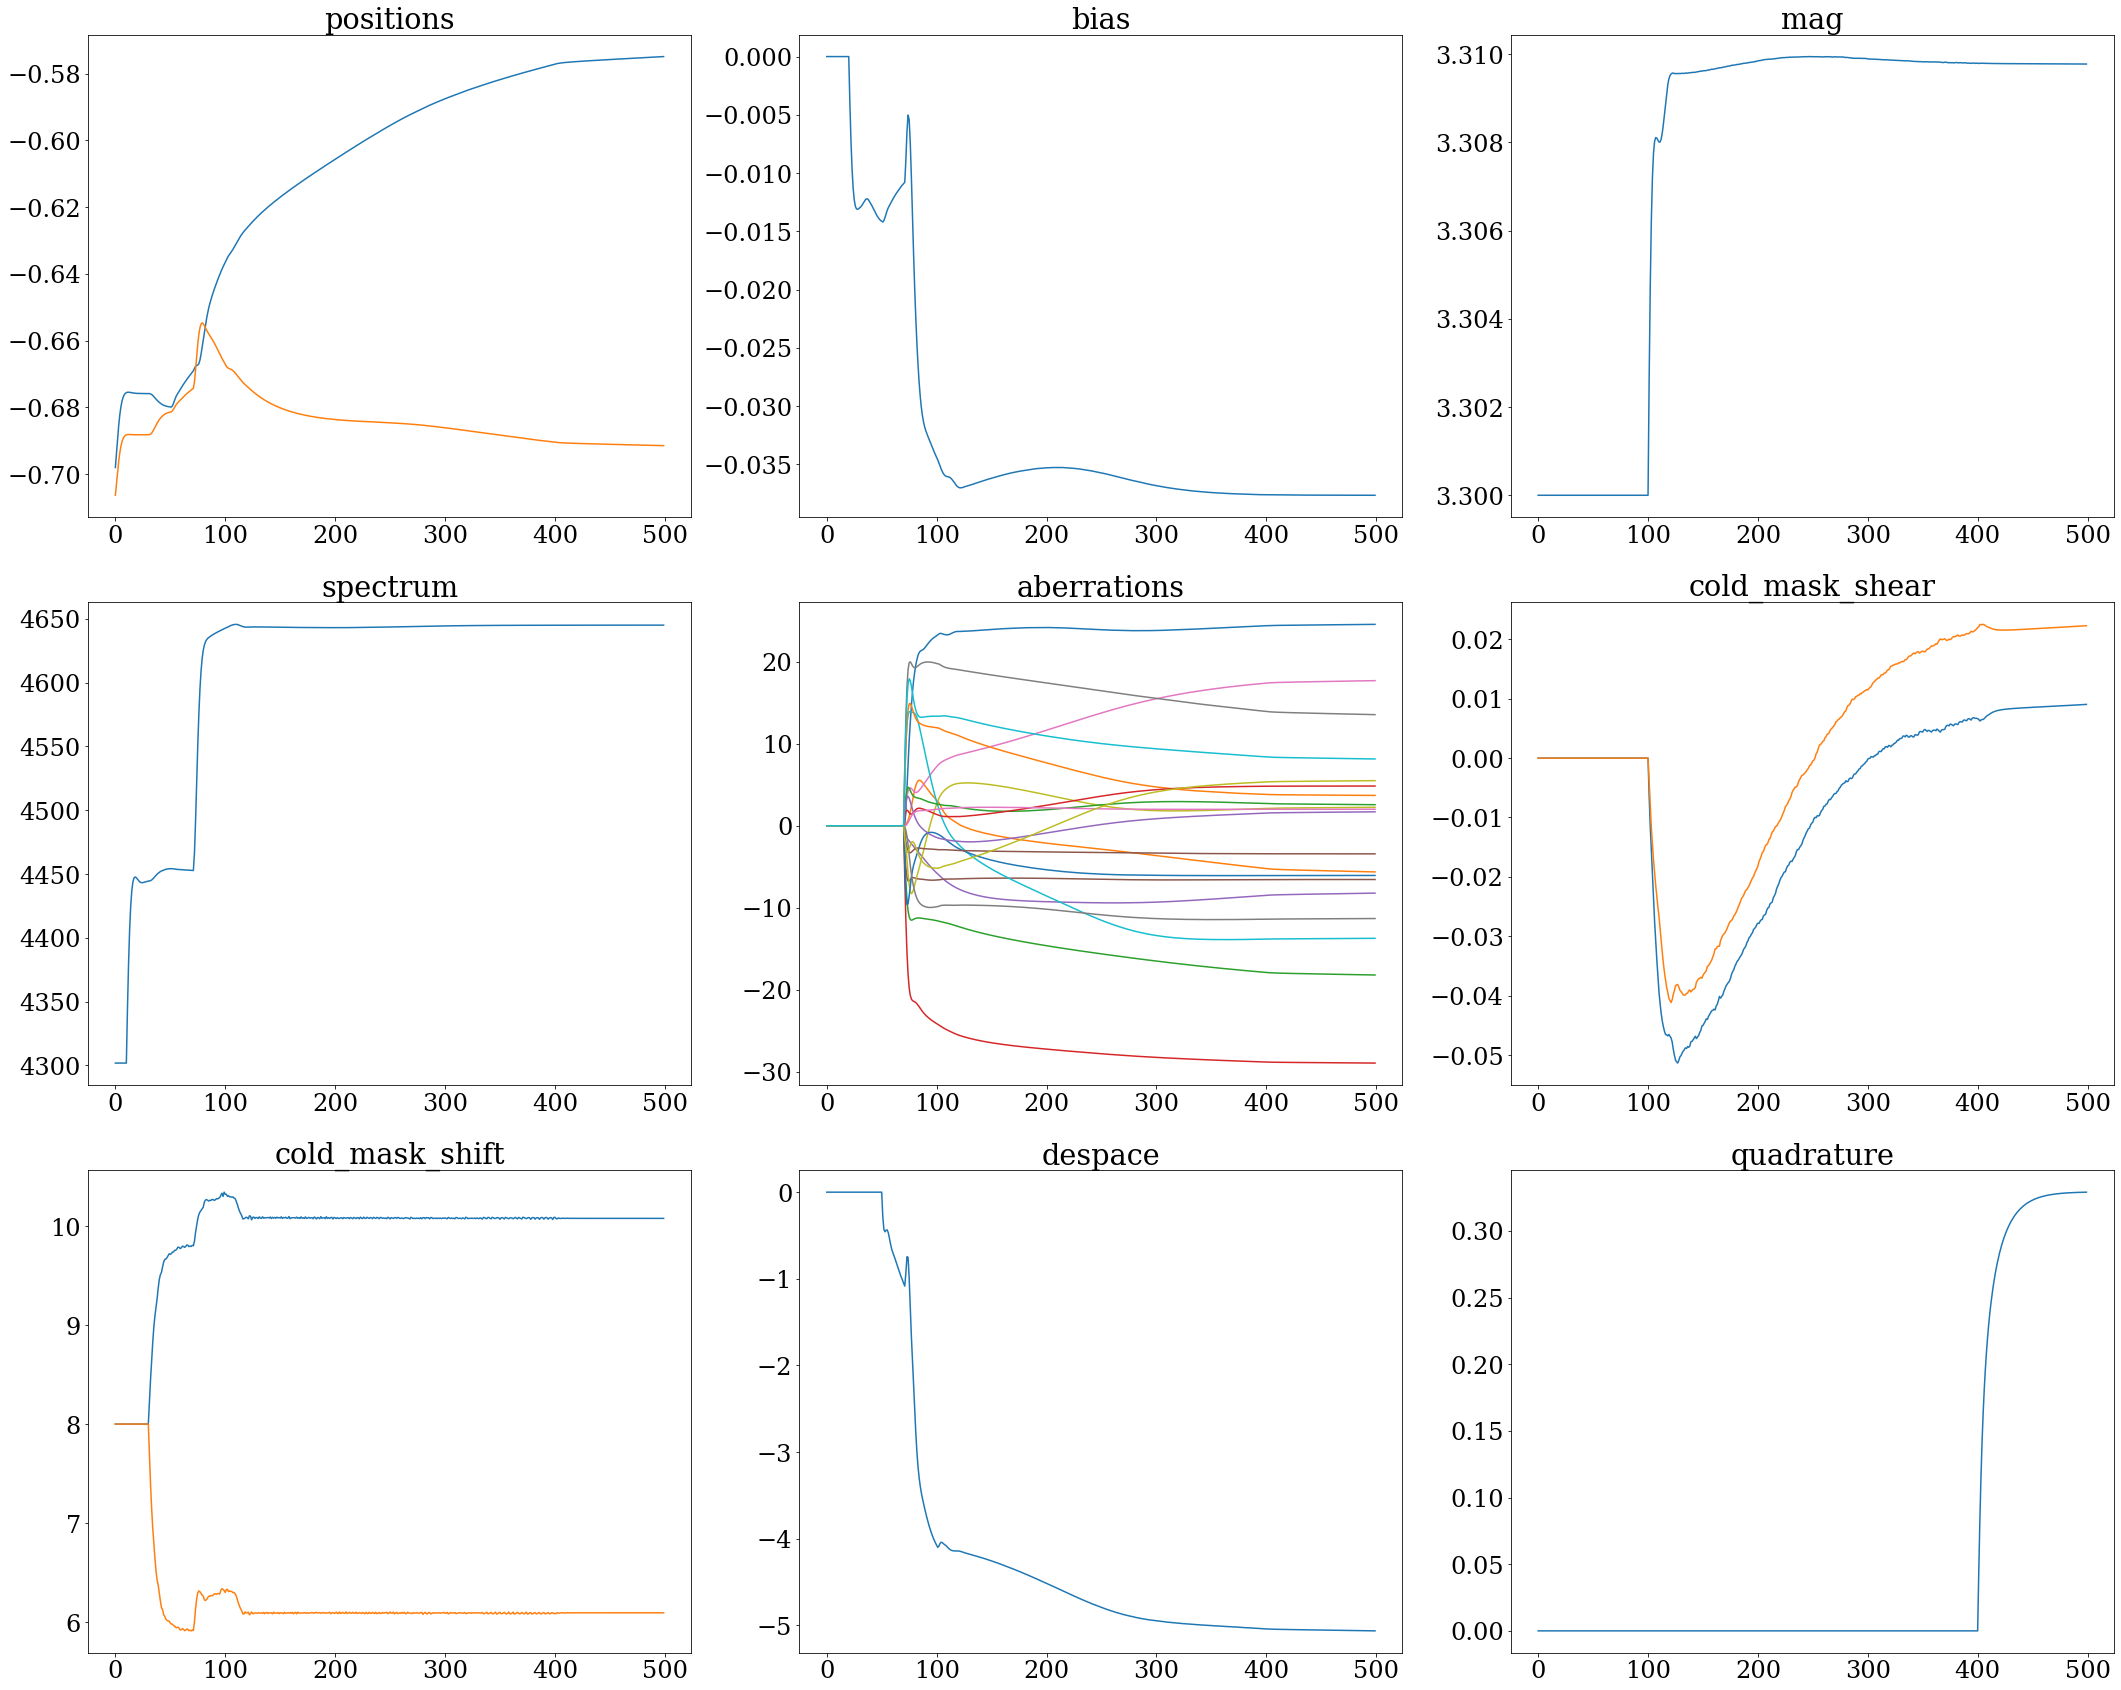

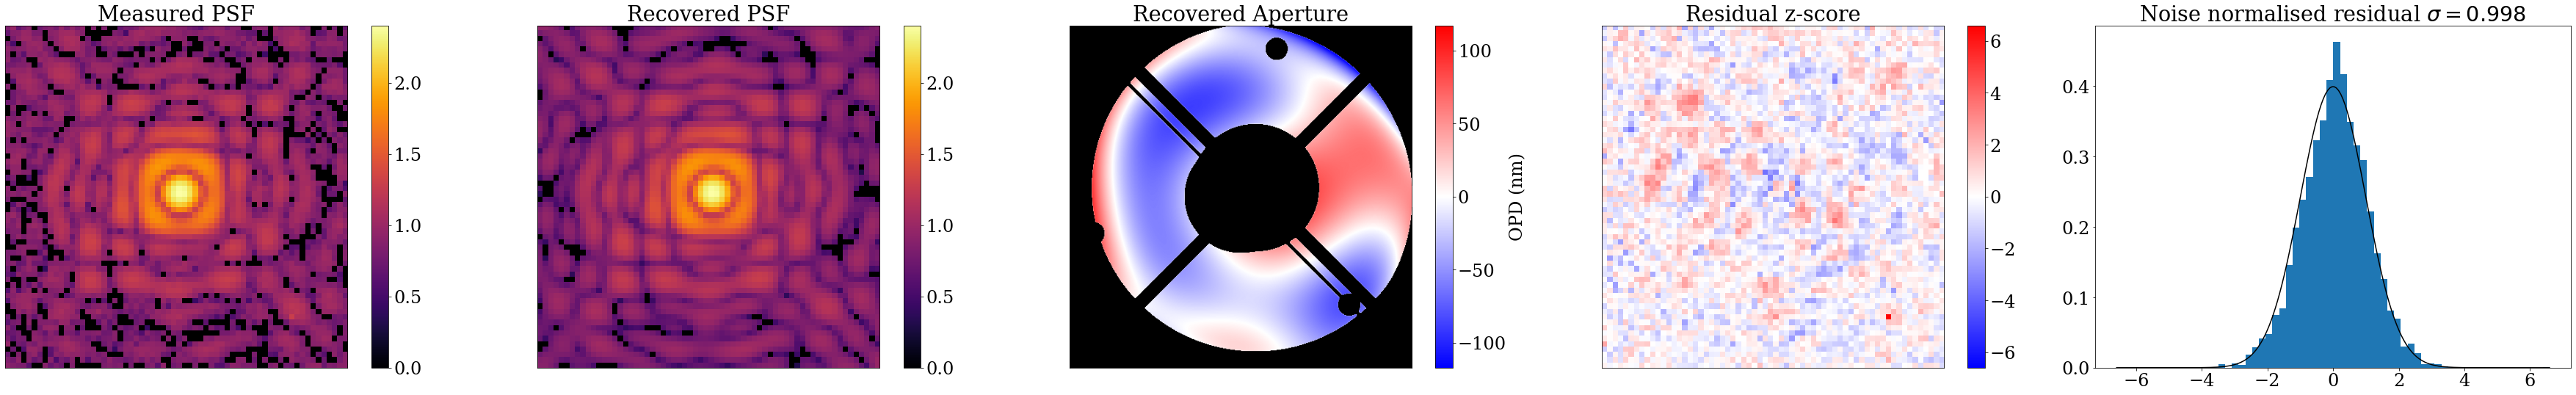

In [15]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [16]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single)

0.997738838033123


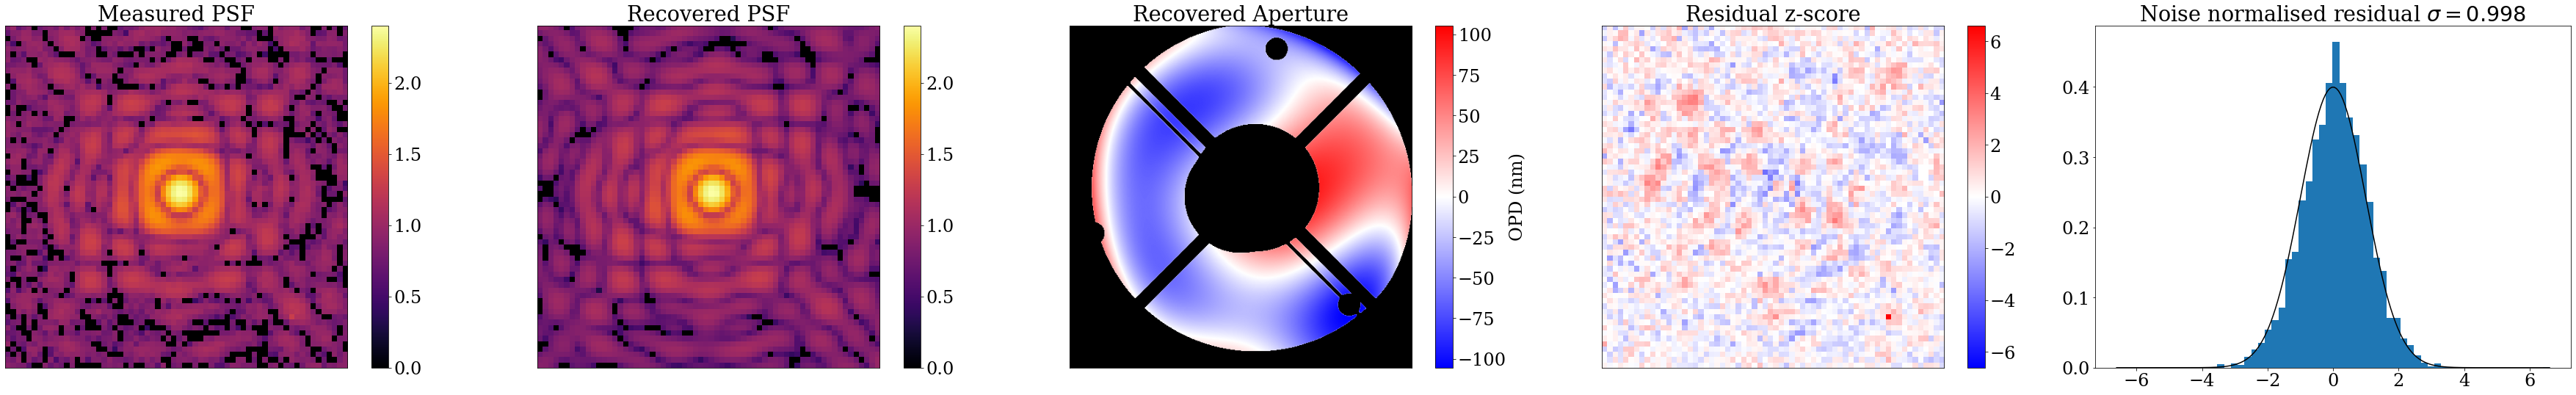

In [17]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [18]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


0.997738838033123


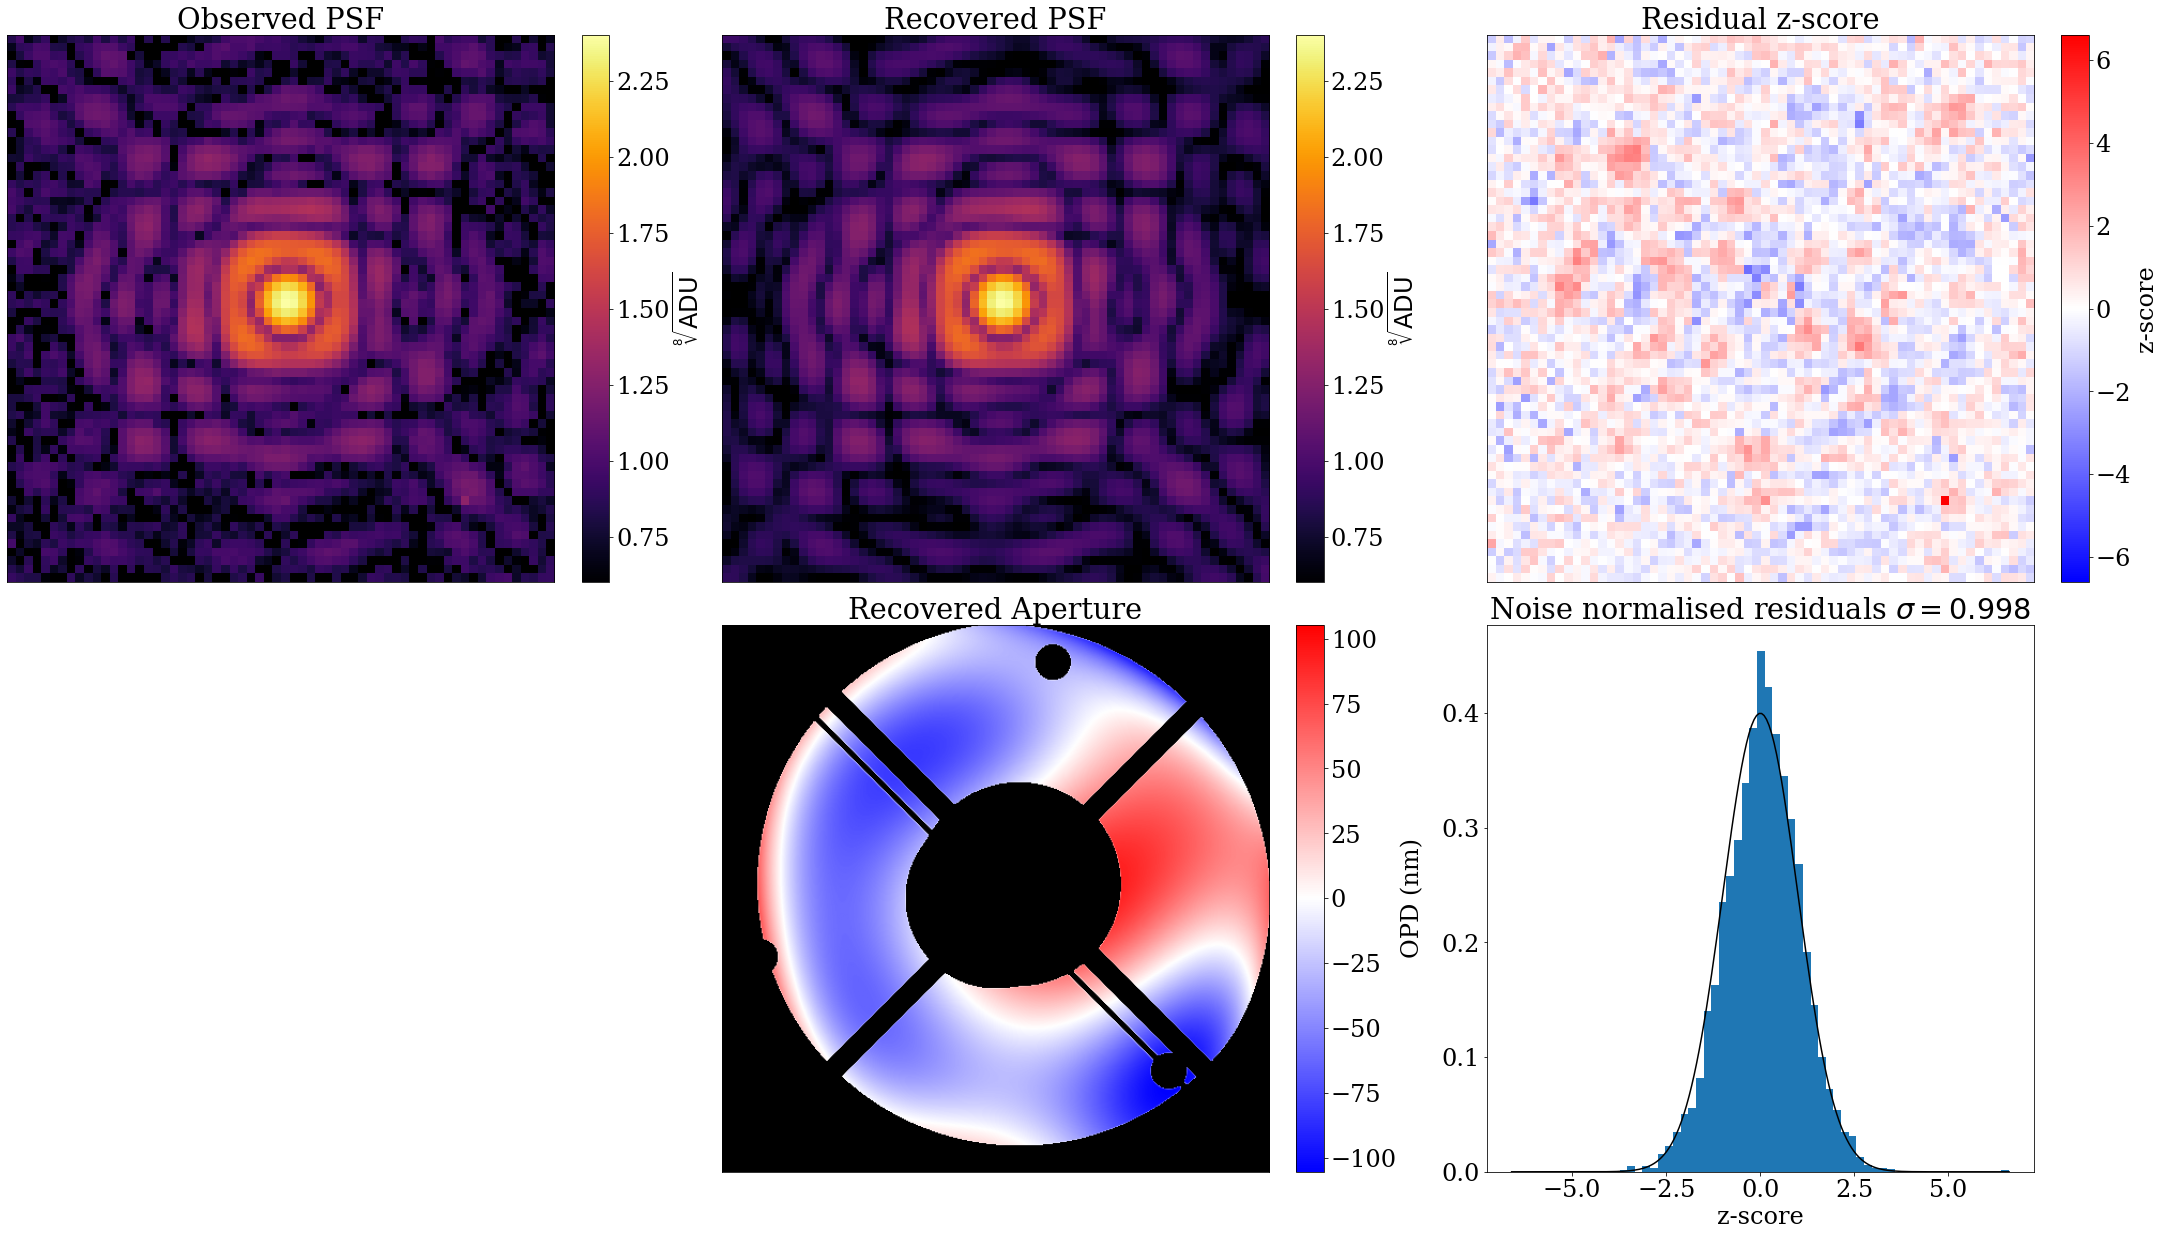

In [19]:
exp = exposures_single[0]
fig, axs = plt.subplots(2,3, figsize=(30,20), layout='compressed')
graticule = False
save=False

ivm = 6e-1


cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)



model = final_params.inject((model_single))

coords = dlu.pixel_coords(512, 2.4)
cropped_frame = exp.data**0.125

fit = exp.fit(model, exp)

wid = fit.shape[0]

telescope_frame = fit**0.125

vm = max(np.nanmax(cropped_frame),np.nanmax(telescope_frame))
cd=axs[0, 0].imshow(cropped_frame, vmin=ivm,vmax=vm,cmap=cmap)
plt.colorbar(cd,ax=axs[0,0], label=r"$\sqrt[8]{\text{ADU}}$")

if graticule:
    axs[0, 0].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0, 0].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

tl=axs[0, 1].imshow(telescope_frame, vmin=ivm, vmax=vm,cmap=cmap)
cbar=plt.colorbar(tl,ax=axs[0,1], label=r"$\sqrt[8]{\text{ADU}}$")
top = vm**8

#ticks = np.linspace(1,vm, 8)**8#np.array([top, top/3, top/10, top/20, top/50, top/100, top/1000])
#cbar.set_ticks(ticks**0.125)
#cbar.set_ticklabels([int(i) for i in ticks])


if graticule:
    axs[0, 1].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0, 1].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

#axs[2].imshow(cropped_err)
cmap = matplotlib.colormaps['bwr']
cmap.set_bad('k',1)

#start_aberrations = model.get(exp.fit.map_param(exp, "start_aberrations"))#*1e-9
#end_aberrations = model.get(exp.fit.map_param(exp, "end_aberrations"))#*1e-9

#aberrations_model = model.set(exp.map_param("aberrations"), (start_aberrations+end_aberrations)/2)

optics = exp.fit.update_optics(model, exp)

support = optics.transmission(coords,2.4/512)
support_mask = support.at[support < .5].set(np.nan)

opd = optics.AberratedAperture.eval_basis(coords)*1e9
olim = np.nanmax(np.abs(opd*support_mask))
apt =axs[1,1].imshow(support_mask*opd,cmap=cmap,vmin=-olim, vmax=olim)
plt.colorbar(apt, ax=axs[1,1]).set_label("OPD (nm)")


resid = (exp.data - fit)/np.sqrt(exp.err**2 + 10**model.get(exp.fit.map_param(exp, "quadrature")))
resid = (exp.data - fit)/(exp.err*10**model.get(exp.fit.map_param(exp, "quadrature")))

print(np.nanstd(resid))
rlim = np.nanmax(np.abs(resid))
residual=axs[0,2].imshow(resid, cmap='bwr',vmin=-rlim, vmax=rlim)
plt.colorbar(residual,ax=axs[0,2]).set_label("z-score")

if graticule:
    axs[0,2].axvline((wid-1)/2 + params.get(exp.map_param("positions"))[0], color='k',linestyle='--')
    axs[0,2].axhline((wid-1)/2 + params.get(exp.map_param("positions"))[1], color='k',linestyle='--')

x = np.nanmax(np.abs(resid))
xs = np.linspace(-x, x, 200)
ys = jsp.stats.norm.pdf(xs, scale=np.nanstd(resid))#/np.sqrt(np.nanstd(resid))

axs[1,2].set_title(fr"Noise normalised residuals $\sigma ={np.nanstd(resid):.3}$")
axs[1,2].hist(resid.flatten(), bins=51, density=True)
axs[1,2].plot(xs, ys, c='k')
axs[1,2].set_xlabel("z-score")
#axs[1,2].set_ylabel("Counts")

#lpdf = posterior(model,exp,return_im=True)#*nanmap
#lpd = axs[4].imshow(lpdf)
#plt.colorbar(lpd, ax=axs[4])

axs[0,0].set_title("Observed PSF")
axs[0,1].set_title("Recovered PSF")
axs[1,1].set_title("Recovered Aperture")
axs[0,2].set_title("Residual z-score")
#axs[4].set_title("Log Likelihood Map")

axs[1,0].set_axis_off()

for i in range(3):
    for j in range(2):
        if (i,j) != (2,1):
            axs[j,i].set_xticks([])
            axs[j,i].set_yticks([])

#fig.tight_layout()

if save:
    fig.savefig(f"{save}_{f}.png")


In [20]:
np.savez("pupil_fit.npz", opd=opd, support=support)

In [21]:
# calculate fisher and make correlation matrix/corner plot

In [22]:
corner_params = ModelParams({k:final_params.params[k] for k in final_params.params if k not in ["aberrations", "bias", "positions", "spectrum", "quadrature"]})

In [23]:
corner_params

ModelParams(
  params={
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'despace': {'n43ca5fhq': f64[]},
    'mag': f64[]
  }
)

In [24]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [25]:
fl, unflat = jax.flatten_util.ravel_pytree(corner_params)

loglike = lambda p: loss_fn(unflat(p), exposures_single, ModelParams(params.params | final_params.params).inject(model_single))

In [26]:
print(fl)
print(corner_params.params)

[ 0.03209002  0.04549327 10.076615    6.09507818 -6.83395456  3.30940466]
{'cold_mask_shear': {'global': Array([0.03209002, 0.04549327], dtype=float64)}, 'cold_mask_shift': {'global': Array([10.076615  ,  6.09507818], dtype=float64)}, 'despace': {'n43ca5fhq': Array(-6.83395456, dtype=float64)}, 'mag': Array(3.30940466, dtype=float64)}


In [27]:
names = [
    r"Cold Mask X Shear (unit)",
    r"Cold Mask Y Shear (unit)",
    r"Cold Mask X Shift (cm)",
    r"Cold Mask Y Shift (cm)",
    r"Despace (µm)",
    r"Magnification",
    #r"Position X",
    #r"Position Y",
    #r"Log Flux"
]

title_names = [
    r"X Shear",
    r"Y Shear",
    r"X Shift",
    r"Y Shift",
    r"Despace",
    r"Mag",
    #r"Position X",
    #r"Position Y",
    #r"Log Flux"
]

names_latex = [rf"$\text{{{x}}}$" for x in names]
names_wrapped = [rf"${x}$" for x in names]
names_title = [rf"\text{{{x}}}" for x in title_names]

In [28]:
labels = {names[i]:names_latex[i] for i in range(len(names))}
title_labels = {names[i]:names_title[i] for i in range(len(names))}

In [29]:
title_labels

{'Cold Mask X Shear (unit)': '\\text{X Shear}',
 'Cold Mask Y Shear (unit)': '\\text{Y Shear}',
 'Cold Mask X Shift (cm)': '\\text{X Shift}',
 'Cold Mask Y Shift (cm)': '\\text{Y Shift}',
 'Despace (µm)': '\\text{Despace}',
 'Magnification': '\\text{Mag}'}

In [30]:
names

['Cold Mask X Shear (unit)',
 'Cold Mask Y Shear (unit)',
 'Cold Mask X Shift (cm)',
 'Cold Mask Y Shift (cm)',
 'Despace (µm)',
 'Magnification']

In [31]:
hessian = jax.hessian(loglike)(fl)

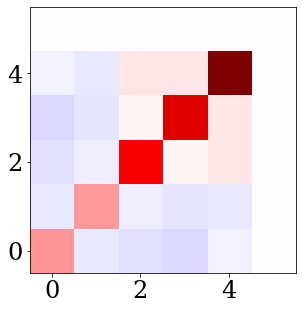

In [32]:
cov = np.linalg.inv(hessian)
vm = np.max(np.abs(cov))
plt.imshow(cov, cmap="seismic", vmax=vm, vmin=-vm)

In [33]:
def cov_to_corr(cov):
    # Calculate the standard deviations
    std = np.sqrt(np.diag(cov))

    # Calculate the correlation matrix
    corr = cov / np.outer(std, std)

    return corr

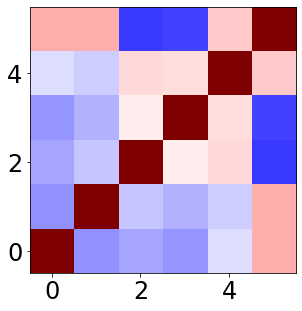

In [40]:
corr = cov_to_corr(cov)
vm = np.max(np.abs(corr))
plt.imshow(corr, cmap="seismic", vmax=vm, vmin=-vm)

In [ ]:
args = np.arange(corr.shape[0])
titles = ["Cold Mask X Shear, Cold Mask Y Shear", "Cold Mask X Shift", "Cold Mask Y Shift", "Despace", "Effective Magnification"]
sorted_labels = [title_labels[i] for i in args]

plt.figure(figsize=(30,20))
plt.imshow(corr[args, :][:, args], origin="upper", cmap="coolwarm")
plt.gca().set_xticks(range(len(plot_names)), sorted_labels, rotation=45, ha='right')
plt.yticks(range(len(plot_names)), sorted_labels)
plt.colorbar()

TypeError: cannot use 'jaxlib._jax.ArrayImpl' as a dict key (unhashable type: 'jaxlib._jax.ArrayImpl')

In [34]:
chn = cc.Chain.from_covariance(fl, cov,names, "chain")

In [42]:
title_labels

{'Cold Mask X Shear (unit)': '\\text{X Shear}',
 'Cold Mask Y Shear (unit)': '\\text{Y Shear}',
 'Cold Mask X Shift (cm)': '\\text{X Shift}',
 'Cold Mask Y Shift (cm)': '\\text{Y Shift}',
 'Despace (µm)': '\\text{Despace}',
 'Magnification': '\\text{Mag}'}

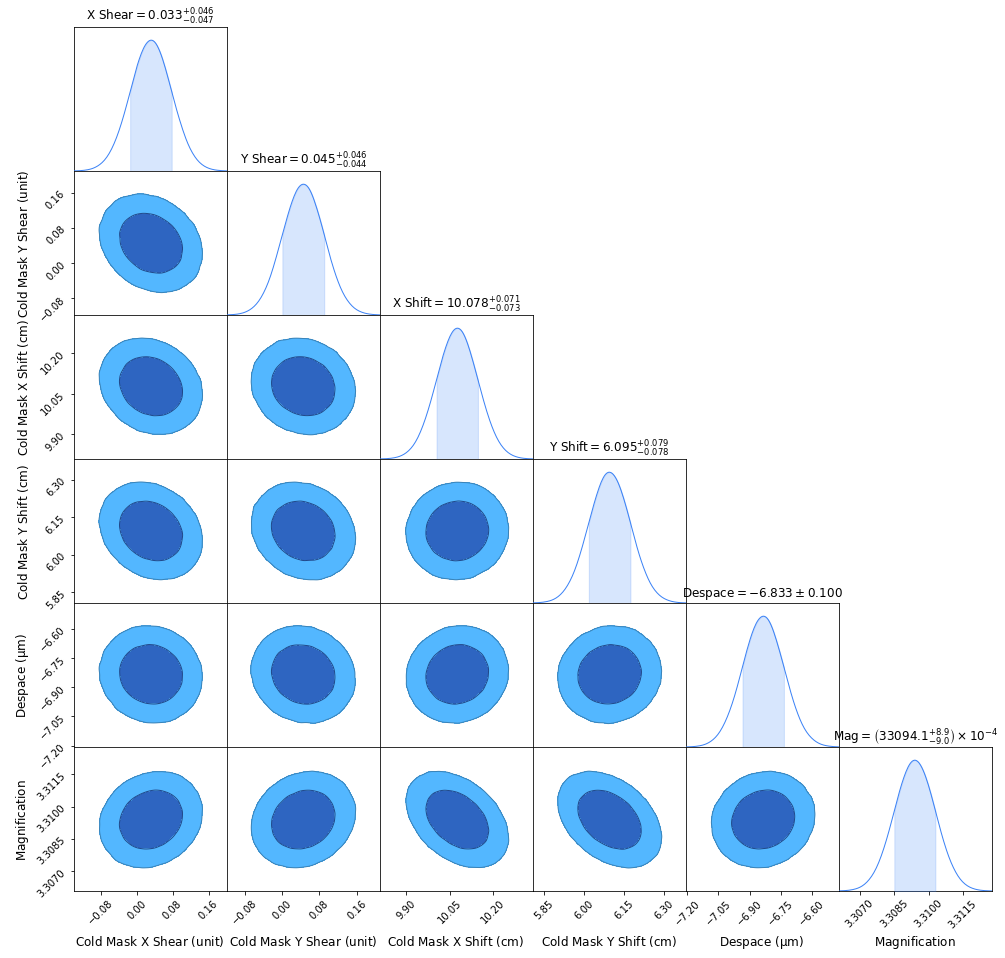

In [36]:
c = cc.ChainConsumer()
c.add_chain(chn)
c.set_plot_config(cc.PlotConfig(labels=labels, title_labels=title_labels,summarise=True))
fig = c.plotter.plot()
fig.align_labels()

In [37]:
fig.align_xlabels()
fig.align_ylabels()
plt.show()

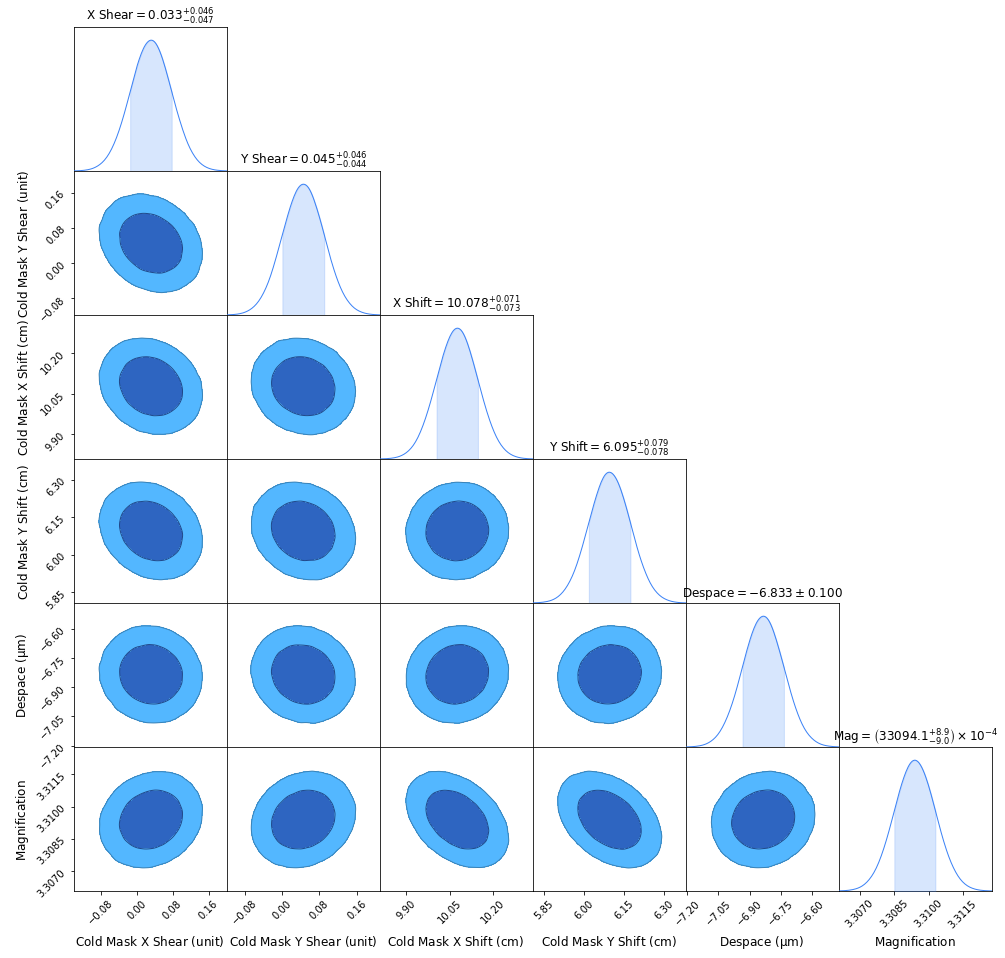

In [38]:
fig